# Custom parity-check matrix `H` + Stim syndrome generation

This notebook lets you:
1. Define a parity-check matrix `H` manually.
2. Build a Stim circuit that measures each check (syndrome bits).
3. Collect `(syndrome, data_measurement)` samples.
4. Plug in your own decoder algorithm and evaluate it.

In [1]:
import numpy as np
import stim
import matplotlib.pyplot as plt

In [2]:
# --- 1) Define your custom H manually (rows=checks, cols=data qubits) ---
H = np.array(
    [
        [1, 1, 1, 1, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0, 0, 0],
        [1, 0, 1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 1, 1],
        [0, 0, 0, 0, 1, 1, 0, 0],
        [0, 0, 0, 0, 1, 0, 1, 0],
    ],
    dtype=np.uint8,
)

def make_H_3anc_per_4data(num_blocks: int) -> np.ndarray:
    """
    Build H with 3 checks per 4 data qubits (block-wise).
    For each block [q0,q1,q2,q3], rows are:
      1) q0+q1+q2+q3
      2) q0+q1
      3) q0+q2
    """
    if num_blocks <= 0:
        raise ValueError("num_blocks must be >= 1")

    H_block = np.array(
        [
            [1, 1, 1, 1],
            [1, 1, 0, 0],
            [1, 0, 1, 0],
        ],
        dtype=np.uint8,
    )
    H_gen = np.kron(np.eye(num_blocks, dtype=np.uint8), H_block).astype(np.uint8)

    return H_gen

# Rebuild H programmatically (matches your 8-column example when num_blocks=2)
H = make_H_3anc_per_4data(3)

assert H.ndim == 2
assert set(np.unique(H)).issubset({0, 1})

num_checks, num_data = H.shape
print(f"H shape: checks={num_checks}, data={num_data}")
print(H)

H shape: checks=9, data=12
[[1 1 1 1 0 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 0 0 0 0]
 [1 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 1 1 1 0 0 0 0]
 [0 0 0 0 1 1 0 0 0 0 0 0]
 [0 0 0 0 1 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 1 1 1]
 [0 0 0 0 0 0 0 0 1 1 0 0]
 [0 0 0 0 0 0 0 0 1 0 1 0]]


In [3]:
def build_syndrome_circuit_from_H(H: np.ndarray, p_data: float = 0.02, p_meas: float = 0.0) -> stim.Circuit:
    """
    Build one-round X-noise memory circuit with Z-check syndrome extraction from H.

    - Data qubits: 0 .. n-1
    - Ancilla/check qubits: n .. n+m-1 (one per row of H)
    - Syndrome bits are ancilla measurements (and matching DETECTOR bits).
    """
    H = (H % 2).astype(np.uint8)
    m, n = H.shape

    data = list(range(n))
    anc = list(range(n, n + m))

    circuit = stim.Circuit()
    circuit.append("R", data + anc)
    circuit.append("X_ERROR", data, float(p_data))

    for i in range(m):
        a = anc[i]
        support = [j for j, bit in enumerate(H[i]) if bit]
        circuit.append("H", [a])
        for q in support:
            circuit.append("CZ", [a, q])
        circuit.append("H", [a])
        if p_meas > 0:
            circuit.append("X_ERROR", [a], float(p_meas))
        circuit.append("M", [a])
        circuit.append("DETECTOR", [stim.target_rec(-1)])

    circuit.append("M", data)
    return circuit


def sample_syndrome_dataset(circuit: stim.Circuit, H: np.ndarray, shots: int = 1000):
    """
    Returns:
      syndromes: shape (shots, m)
      data_meas: shape (shots, n)
    Measurement order in this circuit is [all ancilla M, then all data M].
    """
    m, n = H.shape
    sampler = circuit.compile_sampler()
    meas = sampler.sample(shots=shots).astype(np.uint8)

    syndromes = meas[:, :m]
    data_meas = meas[:, m:m+n]
    return syndromes, data_meas

In [4]:
def decode_batch(syndromes: np.ndarray, H: np.ndarray, decode_one_fn) -> np.ndarray:
    est = [decode_one_fn(s.astype(np.uint8), H) for s in syndromes]
    return np.array(est, dtype=np.uint8)


def evaluate_decoder(H: np.ndarray, syndromes: np.ndarray, data_meas: np.ndarray, decode_one_fn):
    """
    For this simple one-round X-noise model, data Z-basis measurements equal the
    sampled X-error pattern on data qubits. We compare e_hat directly to data_meas.
    """
    e_hat = decode_batch(syndromes, H, decode_one_fn)
    per_shot_fail = np.any((e_hat ^ data_meas) != 0, axis=1)
    block_error_rate = float(np.mean(per_shot_fail))
    return {
        "shots": int(len(syndromes)),
        "fails": int(np.sum(per_shot_fail)),
        "block_error_rate": block_error_rate,
    }

In [5]:
# --- 2) Build circuit and inspect ---
p_data = 0.005
p_meas = 0.0
shots = 5000

circuit = build_syndrome_circuit_from_H(H, p_data=p_data, p_meas=p_meas)

# circuit.diagram("timeline-svg")

In [6]:
# --- 3) Generate syndrome/data dataset ---
syndromes, data_meas = sample_syndrome_dataset(circuit, H, shots=shots)

print("syndromes shape:", syndromes.shape)
print("data_meas shape:", data_meas.shape)
print("first 5 syndrome rows:\n", syndromes[:5])
print("first 5 data rows:\n", data_meas[:5])

# sanity: check that H @ data_meas^T matches syndrome for p_meas=0
pred_syn = (data_meas @ H.T) % 2
consistency = np.mean(np.all(pred_syn == syndromes, axis=1))
print(f"Consistency P(H*e = s): {consistency:.4f}")

syndromes shape: (5000, 9)
data_meas shape: (5000, 12)
first 5 syndrome rows:
 [[0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]]
first 5 data rows:
 [[0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]]
Consistency P(H*e = s): 1.0000


In [7]:
def _build_local_lut_from_H_block(H_block: np.ndarray):
    """Map local syndrome -> minimum-weight 4-bit error for a 3x4 block check matrix."""
    lut = {}
    for mask in range(1 << 4):
        e = np.array([(mask >> j) & 1 for j in range(4)], dtype=np.uint8)
        syn = tuple(((H_block @ e) & 1).tolist())
        w = int(mask.bit_count())
        if syn not in lut or w < lut[syn][0]:
            lut[syn] = (w, e.copy())
    return {k: v[1] for k, v in lut.items()}


def _decode_make_H3_style(s: np.ndarray, n_blocks: int) -> np.ndarray:
    """
    Decode H from make_H_3anc_per_4data (3 checks per 4 data), block-wise.
    This is exact minimum-weight per block because checks are local.
    """
    H_block = np.array(
        [
            [1, 1, 1, 1],
            [1, 1, 0, 0],
            [1, 0, 1, 0],
        ],
        dtype=np.uint8,
    )
    lut = _build_local_lut_from_H_block(H_block)

    e_hat = np.zeros(4 * n_blocks, dtype=np.uint8)
    for b in range(n_blocks):
        syn_local = tuple((s[3 * b:3 * b + 3] & 1).tolist())
        e_local = lut.get(syn_local, np.zeros(4, dtype=np.uint8))
        e_hat[4 * b:4 * b + 4] = e_local
    return e_hat

def custom_decode_one(s: np.ndarray, H: np.ndarray) -> np.ndarray:
    """
    Structure-aware custom decoder aligned with your generated H patterns.

    Supports:
    1) make_H_3anc_per_4data: shape (3B, 4B)
    2) make_H(n):            shape (B+2, 4B)
    """
    H = (H.astype(np.uint8) & 1)
    s = (s.astype(np.uint8) & 1)

    m, n = H.shape
    if n % 4 != 0:
        raise ValueError("This decoder expects number of data qubits to be multiple of 4.")

    n_blocks = n // 4

    # Pattern A: 3 ancillas per 4 data (fully local checks).
    return _decode_make_H3_style(s=s, n_blocks=n_blocks)

Custom decoder metrics: {'shots': 100000, 'fails': 51910, 'block_error_rate': 0.5191}
Custom decoder metrics: {'shots': 100000, 'fails': 8309, 'block_error_rate': 0.08309}
Custom decoder metrics: {'shots': 100000, 'fails': 2143, 'block_error_rate': 0.02143}
Custom decoder metrics: {'shots': 100000, 'fails': 92, 'block_error_rate': 0.00092}
Custom decoder metrics: {'shots': 100000, 'fails': 20, 'block_error_rate': 0.0002}
Custom decoder metrics: {'shots': 100000, 'fails': 0, 'block_error_rate': 0.0}


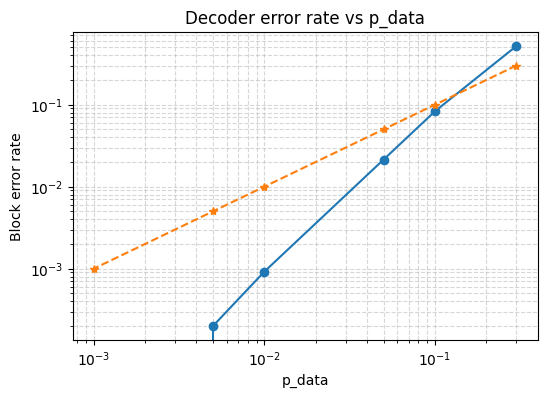

In [8]:
# --- 2) Build circuit and inspect ---
err_rate_array = []
p_data_values = np.array([0.3, 0.1, 0.05, 0.01, 0.005, 0.001], dtype=float)
for p_data in p_data_values:
    p_meas = 0.0
    shots = 1_000_00

    circuit = build_syndrome_circuit_from_H(H, p_data=p_data, p_meas=p_meas)

    # circuit.diagram("timeline-svg")
    syndromes, data_meas = sample_syndrome_dataset(circuit, H, shots=shots)

    # --- 4) Run your custom decoder ---
    metrics = evaluate_decoder(H, syndromes, data_meas, custom_decode_one)
    err_rates = metrics["block_error_rate"]
    err_rate_array.append(err_rates)
    print("Custom decoder metrics:", metrics)

plt.figure(figsize=(6, 4))
plt.loglog(p_data_values, err_rate_array, marker="o")
plt.loglog(p_data_values, p_data_values, marker="*", linestyle="--")
plt.xlabel("p_data")
plt.ylabel("Block error rate")
plt.title("Decoder error rate vs p_data")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

# H2

In [9]:
print(make_H_3anc_per_4data(4))

[[1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0]]


In [14]:
# --- 2) Build circuit and inspect ---
p_meas = 0.0
shots = 1_000_00
n_values = [3,4,5,6] # num of blocks in H (n*4 data qubits)
num_ancillas = [(n*3) for n in n_values]
rates = [n*4/(n*4 + num_ancillas[i]) for i, n in enumerate(n_values)]
p_data_values = np.array([0.3, 0.1, 0.05, 0.01, 0.005, 0.001], dtype=float)
err_rate_over_n = []
for i,n in enumerate(n_values):
    H_2 = make_H_3anc_per_4data(n)
    print("Starting n =", n, "; rate =", rates[i])
    err_rate_array = []
    for p_data in p_data_values:
        circuit = build_syndrome_circuit_from_H(H_2, p_data=p_data, p_meas=p_meas)
        syndromes, data_meas = sample_syndrome_dataset(circuit, H_2, shots=shots)

        # --- 4) Run your custom decoder ---
        metrics = evaluate_decoder(H_2, syndromes, data_meas, custom_decode_one)
        err_rates = metrics["block_error_rate"]
        err_rate_array.append(err_rates)
        print("Custom decoder metrics:", metrics)
    err_rate_over_n.append(err_rate_array)


Starting n = 3 ; rate = 0.5714285714285714
Custom decoder metrics: {'shots': 100000, 'fails': 51982, 'block_error_rate': 0.51982}
Custom decoder metrics: {'shots': 100000, 'fails': 8225, 'block_error_rate': 0.08225}
Custom decoder metrics: {'shots': 100000, 'fails': 2151, 'block_error_rate': 0.02151}
Custom decoder metrics: {'shots': 100000, 'fails': 80, 'block_error_rate': 0.0008}
Custom decoder metrics: {'shots': 100000, 'fails': 17, 'block_error_rate': 0.00017}
Custom decoder metrics: {'shots': 100000, 'fails': 1, 'block_error_rate': 1e-05}
Starting n = 4 ; rate = 0.5714285714285714
Custom decoder metrics: {'shots': 100000, 'fails': 62031, 'block_error_rate': 0.62031}
Custom decoder metrics: {'shots': 100000, 'fails': 10546, 'block_error_rate': 0.10546}
Custom decoder metrics: {'shots': 100000, 'fails': 2875, 'block_error_rate': 0.02875}
Custom decoder metrics: {'shots': 100000, 'fails': 123, 'block_error_rate': 0.00123}
Custom decoder metrics: {'shots': 100000, 'fails': 26, 'block_

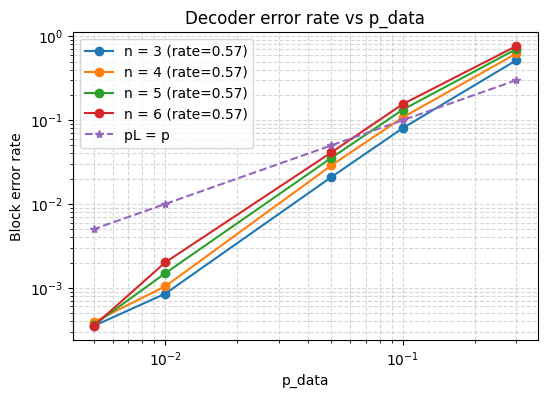

In [ ]:
plt.figure(figsize=(6, 4))
for idx, err_rates in enumerate(err_rate_over_n):
    plt.loglog(p_data_values, err_rates, marker="o", label=f"n = {n_values[idx]} (rate={rates[idx]:.2f})")
plt.loglog(p_data_values, p_data_values, marker="*", linestyle="--", label="pL = p")
plt.xlabel("p_data")
plt.ylabel("Block error rate")
plt.xlim(p_data_values.min(), p_data_values.max())
plt.ylim(1e-4, 1.0)

plt.title("Decoder error rate vs p_data")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

In [62]:
from pathlib import Path
import json

# Real synthesis for logical H: produce one physical Clifford circuit (no commented demo section).

def gf2_rref(A: np.ndarray):
    M = (A.copy() & 1).astype(np.uint8)
    m, n = M.shape
    pivots = []
    r = 0
    for c in range(n):
        pivot = None
        for rr in range(r, m):
            if M[rr, c]:
                pivot = rr
                break
        if pivot is None:
            continue
        if pivot != r:
            M[[r, pivot]] = M[[pivot, r]]
        for rr in range(m):
            if rr != r and M[rr, c]:
                M[rr] ^= M[r]
        pivots.append(c)
        r += 1
        if r == m:
            break
    return M, pivots

def gf2_rank(A: np.ndarray) -> int:
    _, piv = gf2_rref(A)
    return len(piv)

def gf2_nullspace_basis(A: np.ndarray) -> np.ndarray:
    R, piv = gf2_rref(A)
    m, n = R.shape
    free_cols = [c for c in range(n) if c not in piv]
    if not free_cols:
        return np.zeros((0, n), dtype=np.uint8)
    basis = []
    for f in free_cols:
        v = np.zeros(n, dtype=np.uint8)
        v[f] = 1
        for row, pc in enumerate(piv):
            if R[row, f]:
                v[pc] = 1
        basis.append(v)
    return np.array(basis, dtype=np.uint8)

def gf2_solve_one(A: np.ndarray, b: np.ndarray):
    A = (A.copy() & 1).astype(np.uint8)
    b = (b.copy() & 1).astype(np.uint8)
    m, n = A.shape
    Aug = np.hstack([A, b.reshape(-1, 1)])
    r = 0
    pivots = []
    for c in range(n):
        pivot = None
        for rr in range(r, m):
            if Aug[rr, c]:
                pivot = rr
                break
        if pivot is None:
            continue
        if pivot != r:
            Aug[[r, pivot]] = Aug[[pivot, r]]
        for rr in range(m):
            if rr != r and Aug[rr, c]:
                Aug[rr] ^= Aug[r]
        pivots.append(c)
        r += 1
        if r == m:
            break
    for rr in range(m):
        if not np.any(Aug[rr, :n]) and Aug[rr, n]:
            return None
    x = np.zeros(n, dtype=np.uint8)
    for rr, pc in enumerate(pivots):
        x[pc] = Aug[rr, n]
    return x


In [51]:
# Minimum distance of the linear code defined by parity-check matrix H (over GF(2))
# Use existing helper if available (defined later in your notebook), otherwise fallback.
basis = gf2_nullspace_basis(H)  # shape: (k, n)

k, n = basis.shape if basis.ndim == 2 else (0, H.shape[1])

if k == 0:
    print("Only the zero codeword exists. Minimum distance = 0.")
else:
    min_w = n + 1
    min_codewords = []

    # Enumerate all non-zero logical combinations
    for mask in range(1, 1 << k):
        coeff = np.array([(mask >> i) & 1 for i in range(k)], dtype=np.uint8)
        cw = (coeff @ basis) & 1
        w = int(cw.sum())
        if w < min_w:
            min_w = w
            min_codewords = [cw.copy()]
        elif w == min_w:
            min_codewords.append(cw.copy())

    print(f"H shape: {H.shape}, k={k}, n={n}")
    print(f"Minimum distance d_min = {min_w}")
    print(f"Number of minimum-weight codewords found: {len(min_codewords)}")
    print("Example minimum-weight codeword:", min_codewords[0])


H shape: (9, 12), k=3, n=12
Minimum distance d_min = 4
Number of minimum-weight codewords found: 3
Example minimum-weight codeword: [1 1 1 1 0 0 0 0 0 0 0 0]


Synthesized physical Clifford circuit for logical H on q=0.
n=12, k=3, generator-map checks passed: True
Circuit operation count: 5
  OK  X0: ZIIIIIIIIIII  <=  ZIIIIIIIIIII
  OK  Z0: XXXXIIIIIIII  <=  XXXXIIIIIIII
  OK  X1: IIIIXXXXIIII  <=  IIIIXXXXIIII
  OK  Z1: IIIIZIIIIIII  <=  IIIIZIIIIIII
  OK  X2: IIIIIIIIXXXX  <=  IIIIIIIIXXXX
  OK  Z2: IIIIIIIIZIII  <=  IIIIIIIIZIII
Saved to: logical_H_tripleAncillas_q0_timeline.svg


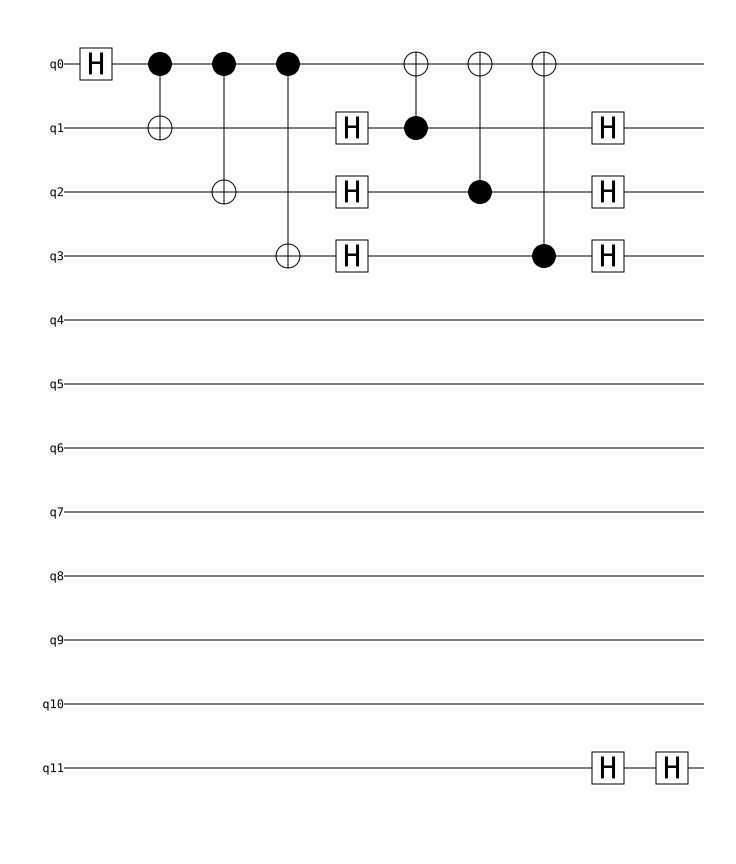

In [63]:
def build_logical_bases_from_H(H_in: np.ndarray):
    H_in = (H_in & 1).astype(np.uint8)
    n = H_in.shape[1]
    X_logical = gf2_nullspace_basis(H_in)
    k = X_logical.shape[0]
    Z_logical = np.zeros((k, n), dtype=np.uint8)
    for j in range(k):
        rhs = np.zeros(k, dtype=np.uint8)
        rhs[j] = 1
        z = gf2_solve_one(X_logical, rhs)
        if z is None:
            raise RuntimeError("Failed to build paired Z logical basis.")
        Z_logical[j] = z
    return {
        "n": int(n),
        "k": int(k),
        "rank_H": int(gf2_rank(H_in)),
        "X_logical_basis": X_logical,
        "Z_logical_basis": Z_logical,
    }

def pauli_str_to_xz(pauli: str):
    p = pauli.strip().upper()
    x = np.zeros(len(p), dtype=np.uint8)
    z = np.zeros(len(p), dtype=np.uint8)
    for i, ch in enumerate(p):
        if ch == "X":
            x[i] = 1
        elif ch == "Z":
            z[i] = 1
        elif ch == "Y":
            x[i] = 1
            z[i] = 1
        elif ch != "I":
            raise ValueError(f"Invalid Pauli char '{ch}' at index {i}.")
    return x, z

def bits_to_pauli(x_bits: np.ndarray, z_bits: np.ndarray) -> str:
    out = []
    for x, z in zip(x_bits.astype(np.uint8), z_bits.astype(np.uint8)):
        if x == 0 and z == 0:
            out.append("I")
        elif x == 1 and z == 0:
            out.append("X")
        elif x == 0 and z == 1:
            out.append("Z")
        else:
            out.append("Y")
    return "".join(out)

def logical_pauli_to_physical(H_in: np.ndarray, logical_pauli: str):
    b = build_logical_bases_from_H(H_in)
    XL = b["X_logical_basis"]
    ZL = b["Z_logical_basis"]
    k, n = b["k"], b["n"]
    lp = logical_pauli.strip().upper()
    if len(lp) != k:
        raise ValueError(f"Expected logical Pauli length k={k}, got {len(lp)}")

    lx = np.zeros(k, dtype=np.uint8)
    lz = np.zeros(k, dtype=np.uint8)
    for i, ch in enumerate(lp):
        if ch == "X":
            lx[i] = 1
        elif ch == "Z":
            lz[i] = 1
        elif ch == "Y":
            lx[i] = 1
            lz[i] = 1
        elif ch != "I":
            raise ValueError(f"Invalid logical Pauli char '{ch}' at index {i}.")

    x_phys = (lx @ XL) % 2 if k > 0 else np.zeros(n, dtype=np.uint8)
    z_phys = (lz @ ZL) % 2 if k > 0 else np.zeros(n, dtype=np.uint8)
    return bits_to_pauli(x_phys, z_phys)

def _pauli_str_to_symplectic_vec(pauli: str) -> np.ndarray:
    x, z = pauli_str_to_xz(pauli)
    return np.concatenate([x, z]).astype(np.uint8)

def _symplectic_vec_to_pauli_str(v: np.ndarray) -> str:
    n = len(v) // 2
    return bits_to_pauli(v[:n], v[n:])

def _gf2_inv(A: np.ndarray) -> np.ndarray:
    A = (A.copy() & 1).astype(np.uint8)
    n, m = A.shape
    if n != m:
        raise ValueError("Matrix must be square for inversion.")
    I = np.eye(n, dtype=np.uint8)
    Aug = np.hstack([A, I])
    r = 0
    for c in range(n):
        pivot = None
        for rr in range(r, n):
            if Aug[rr, c]:
                pivot = rr
                break
        if pivot is None:
            continue
        if pivot != r:
            Aug[[r, pivot]] = Aug[[pivot, r]]
        for rr in range(n):
            if rr != r and Aug[rr, c]:
                Aug[rr] ^= Aug[r]
        r += 1
        if r == n:
            break
    if not np.array_equal(Aug[:, :n], np.eye(n, dtype=np.uint8)):
        raise ValueError("Matrix is singular over GF(2).")
    return Aug[:, n:]

def _gf2_in_row_span(v: np.ndarray, basis_rows: np.ndarray) -> bool:
    v = (v.copy() & 1).astype(np.uint8).reshape(1, -1)
    if basis_rows.size == 0:
        return not np.any(v)
    M = (basis_rows.copy() & 1).astype(np.uint8)
    return gf2_rank(np.vstack([M, v])) == gf2_rank(M)

def _symp_dot(u: np.ndarray, v: np.ndarray) -> int:
    n = len(u) // 2
    ux, uz = u[:n], u[n:]
    vx, vz = v[:n], v[n:]
    return int(((ux @ vz) ^ (uz @ vx)) & 1)

def _orthogonalize_to_pairs(v: np.ndarray, pairs):
    u = (v.copy() & 1).astype(np.uint8)
    for a, b in pairs:
        if _symp_dot(u, b):
            u ^= a
        if _symp_dot(u, a):
            u ^= b
    return u

def _canonical_symplectic_basis(n: int):
    out = []
    for i in range(n):
        v = np.zeros(2*n, dtype=np.uint8); v[i] = 1
        out.append(v)
    for i in range(n):
        v = np.zeros(2*n, dtype=np.uint8); v[n+i] = 1
        out.append(v)
    return out

def _extend_symplectic_pairs(initial_pairs, n: int):
    pairs = [(a.copy().astype(np.uint8), b.copy().astype(np.uint8)) for a, b in initial_pairs]
    canon = _canonical_symplectic_basis(n)

    def current_span_rows():
        if not pairs:
            return np.zeros((0, 2*n), dtype=np.uint8)
        return np.array([v for ab in pairs for v in ab], dtype=np.uint8)

    while len(pairs) < n:
        span_rows = current_span_rows()
        a_new = None
        for cand in canon:
            if _gf2_in_row_span(cand, span_rows):
                continue
            a = _orthogonalize_to_pairs(cand, pairs)
            if not np.any(a):
                continue
            if _gf2_in_row_span(a, span_rows):
                continue
            a_new = a
            break
        if a_new is None:
            raise RuntimeError("Failed to find next symplectic basis vector a.")

        b_new = None
        for cand in canon:
            if _symp_dot(a_new, cand) == 0:
                continue
            b = _orthogonalize_to_pairs(cand, pairs)
            if _symp_dot(a_new, b) != 1:
                continue
            if _gf2_in_row_span(b, np.vstack([span_rows, a_new])):
                continue
            b_new = b
            break
        if b_new is None:
            raise RuntimeError("Failed to find partner symplectic basis vector b.")

        pairs.append((a_new, b_new))

    return pairs

def _logical_single_pauli(k: int, idx: int, p: str) -> str:
    s = ["I"] * k
    s[idx] = p
    return "".join(s)

def synthesize_physical_circuit_for_logical_H(H_in: np.ndarray, q: int, method: str = "elimination"):
    b = build_logical_bases_from_H(H_in)
    n = b["n"]
    k = b["k"]
    if not (0 <= q < k):
        raise ValueError(f"q must be in [0, {k-1}] for this code.")

    domain_pairs = []
    codomain_pairs = []
    expected_map = {}

    for i in range(k):
        Xin_log = _logical_single_pauli(k, i, "X")
        Zin_log = _logical_single_pauli(k, i, "Z")
        Xphys_in = logical_pauli_to_physical(H_in, Xin_log)
        Zphys_in = logical_pauli_to_physical(H_in, Zin_log)

        if i == q:
            Xout_log = _logical_single_pauli(k, i, "Z")
            Zout_log = _logical_single_pauli(k, i, "X")
        else:
            Xout_log = Xin_log
            Zout_log = Zin_log

        Xphys_out = logical_pauli_to_physical(H_in, Xout_log)
        Zphys_out = logical_pauli_to_physical(H_in, Zout_log)

        domain_pairs.append((_pauli_str_to_symplectic_vec(Xphys_in), _pauli_str_to_symplectic_vec(Zphys_in)))
        codomain_pairs.append((_pauli_str_to_symplectic_vec(Xphys_out), _pauli_str_to_symplectic_vec(Zphys_out)))

        expected_map[f"X{i}"] = Xphys_out
        expected_map[f"Z{i}"] = Zphys_out

    D_pairs = _extend_symplectic_pairs(domain_pairs, n)
    C_pairs = _extend_symplectic_pairs(codomain_pairs, n)

    D_cols = [a for a, _ in D_pairs] + [b for _, b in D_pairs]
    C_cols = [a for a, _ in C_pairs] + [b for _, b in C_pairs]
    D = np.stack(D_cols, axis=1).astype(np.uint8)
    C = np.stack(C_cols, axis=1).astype(np.uint8)
    F = (C @ _gf2_inv(D)) % 2

    xs = [stim.PauliString(_symplectic_vec_to_pauli_str(F[:, j])) for j in range(n)]
    zs = [stim.PauliString(_symplectic_vec_to_pauli_str(F[:, n + j])) for j in range(n)]

    tableau = stim.Tableau.from_conjugated_generators(xs=xs, zs=zs)
    circuit = tableau.to_circuit(method=method)

    checks = {}
    for i in range(k):
        for p in ("X", "Z"):
            key = f"{p}{i}"
            in_log = _logical_single_pauli(k, i, p)
            in_phys = logical_pauli_to_physical(H_in, in_log)
            vin = _pauli_str_to_symplectic_vec(in_phys)
            got = _symplectic_vec_to_pauli_str((F @ vin) % 2)
            checks[key] = {
                "ok": got == expected_map[key],
                "expected": expected_map[key],
                "got": got,
            }

    return {
        "n": n,
        "k": k,
        "q": q,
        "tableau": tableau,
        "circuit": circuit,
        "checks": checks,
    }

# Example: one synthesized physical circuit for logical H on selected logical qubit
logical_q = 0
synth = synthesize_physical_circuit_for_logical_H(H, q=logical_q, method="elimination")
all_ok = all(v["ok"] for v in synth["checks"].values())
print(f"Synthesized physical Clifford circuit for logical H on q={logical_q}.")
print(f"n={synth['n']}, k={synth['k']}, generator-map checks passed: {all_ok}")
print(f"Circuit operation count: {len(synth['circuit'])}")

for gen, info in synth["checks"].items():
    tag = "OK" if info["ok"] else "MISMATCH"
    print(f"  {tag}  {gen}: {info['expected']}  <=  {info['got']}")

svg_text = str(synth["circuit"].diagram("timeline-svg"))
svg_path = f"logical_H_tripleAncillas_q{synth['q']}_timeline.svg"
with open(svg_path, "w", encoding="utf-8") as f:
    f.write(svg_text)
print(f"Saved to: {svg_path}")

synth["circuit"].diagram("timeline-svg")